# Branch Wait-Time Prediction

---

## Project context

Notebooks 01 and 02 established that a Random Forest and a Ridge baseline achieve comparable test R² (~0.73) when evaluated on a single held-out period. A single train-test split is a fragile basis for model selection: a different cutoff date could produce a different ranking. This notebook addresses that by introducing time-series cross-validation, which evaluates each model across five consecutive training-and-test windows and produces a more reliable estimate of generalization performance.

A gradient boosting model is added as a third candidate. Unlike a Random Forest - which averages many independent deep trees - gradient boosting builds trees sequentially, each one correcting the residual errors of the previous. This sequential correction is particularly effective when a subset of high-error predictions (here, high-volume branch-days) dominates the loss function.

The notebook closes with SHAP (SHapley Additive exPlanations) values, which decompose each individual prediction into signed feature contributions. This is the layer of explainability that moves the project from a black-box accuracy exercise into something a recruiter or stakeholder can actually interrogate.

## Inputs

| File | Description |
|---|---|
| `data/processed/daily_branch_features.csv` | Feature matrix with lag and rolling features from Notebook 02 |

## Outputs

| File | Description |
|---|---|
| `outputs/figures/03_cv_comparison.png` | Cross-validated R² distributions across three models |
| `outputs/figures/03_model_comparison_scatter.png` | Actual vs predicted for all three models on the test set |
| `outputs/figures/03_residual_by_volume.png` | Mean absolute error by daily volume band |
| `outputs/figures/03_shap_summary.png` | SHAP beeswarm summary plot |
| `outputs/figures/03_shap_waterfall.png` | SHAP waterfall for a high-error prediction |
| `models/gbm_wait_time_pipeline.joblib` | Serialized gradient boosting pipeline |

## 1. Environment setup and data load

The feature matrix produced in Notebook 02 already contains lag and rolling features and the smoothed branch target encoding. Loading it directly avoids repeating the feature engineering logic and ensures the train-test split is identical across notebooks.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import joblib

# ── Paths ──────────────────────────────────────────────────────────────────────
PROC = "../data/processed/"
OUTF = "../outputs/figures/"
OUTM = "../models/"

# ── Load feature matrix ────────────────────────────────────────────────────────
df = pd.read_csv(PROC + "daily_branch_features.csv")
df["Visit Date"] = pd.to_datetime(df["Visit Date"])
df = df.sort_values(["Branch ID", "Visit Date"]).reset_index(drop=True)

print(f"Loaded: {len(df):,} rows  |  {df['Branch ID'].nunique()} branches")
df.head()

Loaded: 16,647 rows  |  72 branches


,Branch ID,Visit Date,p80_wait_min,daily_volume,lag1_p80,lag1_vol,roll5_p80,roll5_vol,month,week_of_year,dow_sin,dow_cos,is_appt_day,branch_te,region,site_type
0,#003,2024-01-04,36.513333,519,28.273333,468.0,31.713333,484.000000,1,1,0.433884,-0.900969,0,30.310597,Central,External
1,#003,2024-01-05,45.750000,504,36.513333,519.0,33.313333,495.666667,1,1,-0.433884,-0.900969,0,30.310597,Central,External
2,#003,2024-01-08,17.740000,186,45.750000,504.0,36.422500,497.750000,1,2,0.000000,1.000000,0,30.310597,Central,External
3,#003,2024-01-09,21.633333,372,17.740000,186.0,32.686000,435.400000,1,2,0.781831,0.623490,0,30.310597,Central,External
4,#003,2024-01-10,16.503333,245,21.633333,372.0,29.982000,409.800000,1,2,0.974928,-0.222521,0,30.310597,Central,External


## 2. Feature matrix and train-test split

The same 80/20 chronological split used in Notebook 02 is reproduced here so that test-set metrics are directly comparable across all three notebooks. The cutoff falls at 2025-07-16, leaving approximately five months of unseen branch-days for evaluation.

In [2]:
NUM_FEATURES = [
    "daily_volume", "lag1_p80", "lag1_vol", "roll5_p80", "roll5_vol",
    "month", "week_of_year", "dow_sin", "dow_cos", "is_appt_day", "branch_te",
]
CAT_FEATURES = ["region", "site_type"]
FEATURE_COLS = NUM_FEATURES + CAT_FEATURES
TARGET       = "p80_wait_min"

dates  = df["Visit Date"].sort_values().unique()
cutoff = dates[int(len(dates) * 0.80)]

train = df[df["Visit Date"] < cutoff].copy()
test  = df[df["Visit Date"] >= cutoff].copy()

X_train, y_train = train[FEATURE_COLS], train[TARGET]
X_test,  y_test  = test[FEATURE_COLS],  test[TARGET]

print(f"Cutoff : {cutoff.date()}")
print(f"Train  : {len(train):,} rows  ({train['Visit Date'].min().date()} to {train['Visit Date'].max().date()})")
print(f"Test   : {len(test):,} rows  ({test['Visit Date'].min().date()} to {test['Visit Date'].max().date()})")

Cutoff : 2025-07-16
Train  : 13,388 rows  (2024-01-04 to 2025-07-15)
Test   : 3,259 rows  (2025-07-16 to 2025-11-29)


## 3. Preprocessing pipelines

Each model uses a shared preprocessing layout: numeric features pass through (or are standardized for Ridge), and the two low-cardinality categorical features (region, site type) are one-hot encoded. Branch identity is already represented by the `branch_te` numeric column from Notebook 02, so no additional encoding is needed here.

In [3]:
# Shared preprocessor for tree-based models (no scaling needed)
pre_tree = ColumnTransformer([
    ("num", "passthrough",                                              NUM_FEATURES),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CAT_FEATURES),
])

# Preprocessor for Ridge (numeric features standardized)
pre_linear = ColumnTransformer([
    ("num", StandardScaler(),                                           NUM_FEATURES),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CAT_FEATURES),
])

ridge_pipeline = Pipeline([
    ("preprocessor", pre_linear),
    ("model",        Ridge(alpha=10.0)),
])

rf_pipeline = Pipeline([
    ("preprocessor", pre_tree),
    ("model",        RandomForestRegressor(
        n_estimators=300, min_samples_leaf=5, n_jobs=-1, random_state=42,
    )),
])

gbm_pipeline = Pipeline([
    ("preprocessor", pre_tree),
    ("model",        GradientBoostingRegressor(
        n_estimators=400, learning_rate=0.05, max_depth=4,
        min_samples_leaf=10, subsample=0.8, random_state=42,
    )),
])

print("Pipelines defined: Ridge, Random Forest, Gradient Boosting")

Pipelines defined: Ridge, Random Forest, Gradient Boosting


## 4. Time-series cross-validation

A standard k-fold cross-validation randomly shuffles rows into folds, which creates temporal leakage: a model could train on a Tuesday and validate on the previous Monday. `TimeSeriesSplit` avoids this by always training on earlier data and validating on later data, expanding the training window with each fold. Five folds are used, each covering roughly three months of held-out data within the training period.

Cross-validated R² distributions are more informative than a single test score because they reveal whether model performance is stable across time or driven by a favorable evaluation window.

In [4]:
tss = TimeSeriesSplit(n_splits=5)

# Sort training data chronologically for TimeSeriesSplit
train_sorted = train.sort_values("Visit Date")
X_tr_s = train_sorted[FEATURE_COLS]
y_tr_s = train_sorted[TARGET]

cv_results = {}
for name, pipeline in [
    ("Ridge",            ridge_pipeline),
    ("Random Forest",    rf_pipeline),
    ("Gradient Boosting", gbm_pipeline),
]:
    scores = cross_val_score(
        pipeline, X_tr_s, y_tr_s,
        cv=tss, scoring="r2", n_jobs=-1,
    )
    cv_results[name] = scores
    print(f"{name:20s}  folds={scores.round(3)}  mean={scores.mean():.3f}  std={scores.std():.3f}")

Ridge                 folds=[0.796 0.841 0.819 0.667 0.714]  mean=0.767  std=0.066
Random Forest         folds=[0.766 0.828 0.828 0.65  0.698]  mean=0.754  std=0.071
Gradient Boosting     folds=[0.747 0.804 0.841 0.642 0.702]  mean=0.747  std=0.071


Saved -> outputs/figures/03_cv_comparison.png


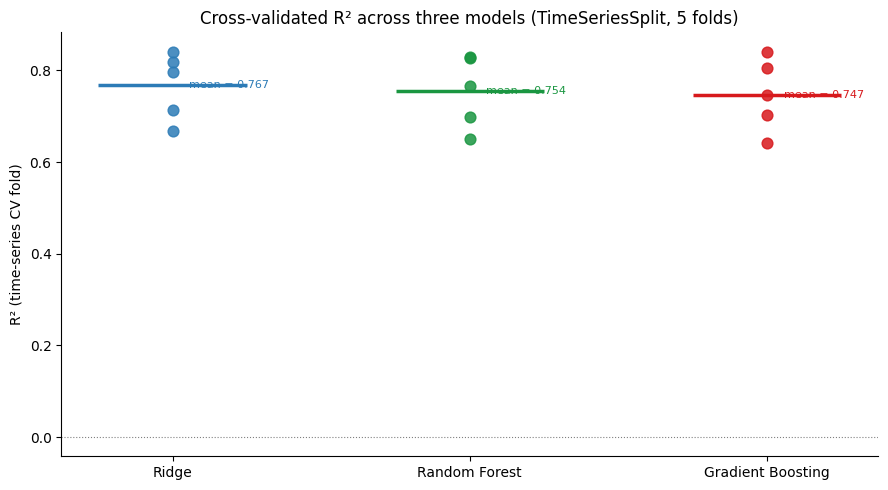

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))

models   = list(cv_results.keys())
positions = np.arange(len(models))
colors    = ["#2c7bb6", "#1a9641", "#d7191c"]

for pos, (name, color) in enumerate(zip(models, colors)):
    scores = cv_results[name]
    ax.scatter(
        [pos] * len(scores), scores,
        color=color, s=60, zorder=3, alpha=0.85,
    )
    ax.hlines(
        scores.mean(), pos - 0.25, pos + 0.25,
        color=color, lw=2.5, zorder=4,
    )
    ax.annotate(
        f"mean = {scores.mean():.3f}",
        xy=(pos, scores.mean()),
        xytext=(12, 0), textcoords="offset points",
        va="center", fontsize=8, color=color,
    )

ax.set_xticks(positions)
ax.set_xticklabels(models)
ax.set_ylabel("R² (time-series CV fold)")
ax.set_title("Cross-validated R² across three models (TimeSeriesSplit, 5 folds)")
ax.axhline(0, color="black", lw=0.8, ls=":", alpha=0.5)
ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
fig.savefig(OUTF + "03_cv_comparison.png", dpi=150, bbox_inches="tight")
print("Saved -> outputs/figures/03_cv_comparison.png")

## 5. Test-set evaluation

All three models are now fit on the full training set and evaluated on the held-out test period. This is the final performance estimate - not to be used for model selection (that decision was made on CV scores above) but to report generalization accuracy on truly unseen data.

In [6]:
results = {}

for name, pipeline in [
    ("Ridge",             ridge_pipeline),
    ("Random Forest",     rf_pipeline),
    ("Gradient Boosting", gbm_pipeline),
]:
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    results[name] = {
        "pipeline": pipeline,
        "y_pred":   y_pred,
        "r2":       r2_score(y_test, y_pred),
        "mae":      mean_absolute_error(y_test, y_pred),
        "rmse":     np.sqrt(mean_squared_error(y_test, y_pred)),
    }
    print(f"{name:20s}  R2={results[name]['r2']:.4f}  MAE={results[name]['mae']:.3f}  RMSE={results[name]['rmse']:.3f}")

Ridge                 R2=0.7252  MAE=6.123  RMSE=8.860
Random Forest         R2=0.7316  MAE=5.997  RMSE=8.756
Gradient Boosting     R2=0.7127  MAE=6.133  RMSE=9.060


Saved -> outputs/figures/03_model_comparison_scatter.png


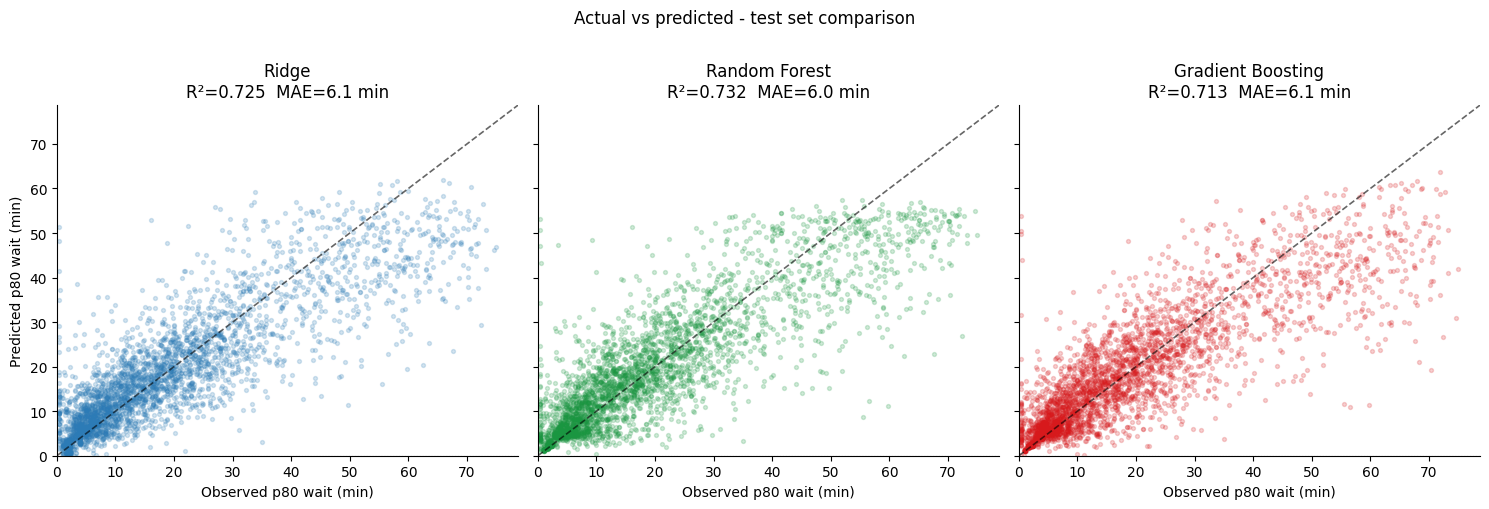

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True, sharex=True)
colors = ["#2c7bb6", "#1a9641", "#d7191c"]

for ax, (name, res), color in zip(axes, results.items(), colors):
    ax.scatter(
        y_test, res["y_pred"],
        alpha=0.20, s=8, color=color, rasterized=True,
    )
    lim = max(y_test.max(), res["y_pred"].max()) * 1.05
    ax.plot([0, lim], [0, lim], ls="--", lw=1.2, color="black", alpha=0.6)
    ax.axhline(0, color="black", lw=0.8, ls=":", alpha=0.4)
    ax.set_xlim(0, lim)
    ax.set_ylim(0, lim)
    ax.set_title(f"{name}\nR²={res['r2']:.3f}  MAE={res['mae']:.1f} min")
    ax.set_xlabel("Observed p80 wait (min)")
    ax.spines[["top", "right"]].set_visible(False)

axes[0].set_ylabel("Predicted p80 wait (min)")
fig.suptitle("Actual vs predicted - test set comparison", y=1.01)
fig.tight_layout()
fig.savefig(OUTF + "03_model_comparison_scatter.png", dpi=150, bbox_inches="tight")
print("Saved -> outputs/figures/03_model_comparison_scatter.png")

## 6. Residual analysis by volume band

All three models show increasing absolute error at higher daily volumes - a consistent pattern that reflects genuine heteroscedasticity in the data rather than a modeling deficiency. High-volume branch-days have more volatile wait times (a single staffing gap or unexpected surge can shift the p80 dramatically), so predictions for those days carry more uncertainty by construction.

Understanding where the model fails is as important as understanding where it succeeds, particularly if predictions are used to trigger operational interventions.

Saved -> outputs/figures/03_residual_by_volume.png


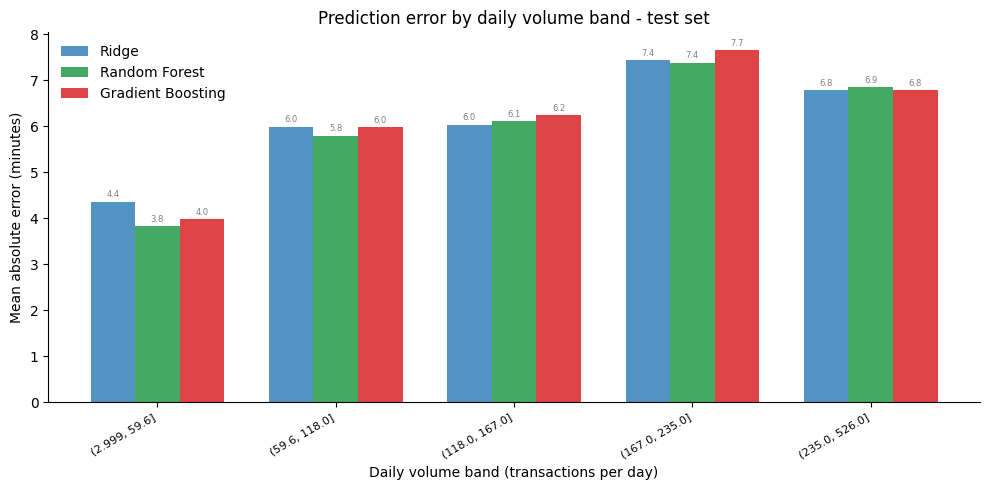

In [8]:
test_eval = test[["Branch ID", "Visit Date", "daily_volume", "site_type", TARGET]].copy()

for name, res in results.items():
    test_eval[f"pred_{name.replace(' ', '_')}"] = res["y_pred"]
    test_eval[f"err_{name.replace(' ', '_')}"]  = (res["y_pred"] - test_eval[TARGET]).abs()

test_eval["vol_band"] = pd.qcut(
    test_eval["daily_volume"], q=5, duplicates="drop"
)

fig, ax = plt.subplots(figsize=(10, 5))

n_bands   = test_eval["vol_band"].nunique()
bands     = sorted(test_eval["vol_band"].dropna().unique())
x         = np.arange(len(bands))
bar_width = 0.25
colors    = ["#2c7bb6", "#1a9641", "#d7191c"]
names     = ["Ridge", "Random_Forest", "Gradient_Boosting"]
labels    = ["Ridge", "Random Forest", "Gradient Boosting"]

for offset, (col_suffix, label, color) in enumerate(zip(names, labels, colors)):
    maes = [
        test_eval.loc[test_eval["vol_band"] == b, f"err_{col_suffix}"].mean()
        for b in bands
    ]
    bars = ax.bar(
        x + offset * bar_width, maes,
        width=bar_width, label=label, color=color, alpha=0.82,
    )
    for bar, val in zip(bars, maes):
        ax.annotate(
            f"{val:.1f}",
            xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
            xytext=(0, 3), textcoords="offset points",
            ha="center", fontsize=6, color="gray",
        )

ax.set_xticks(x + bar_width)
ax.set_xticklabels([str(b) for b in bands], rotation=30, ha="right", fontsize=8)
ax.set_xlabel("Daily volume band (transactions per day)")
ax.set_ylabel("Mean absolute error (minutes)")
ax.set_title("Prediction error by daily volume band - test set")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
fig.savefig(OUTF + "03_residual_by_volume.png", dpi=150, bbox_inches="tight")
print("Saved -> outputs/figures/03_residual_by_volume.png")

## 7. SHAP feature contributions

SHAP values quantify each feature's signed contribution to a specific prediction relative to the model's baseline (the expected output over all training observations). A positive SHAP value means the feature pushed the prediction higher than average; a negative value means it pulled it lower. Unlike permutation importance, which gives a single global ranking, SHAP values are computed per prediction, making it possible to explain why the model flagged a particular branch-day as high-risk.

The beeswarm plot below shows the distribution of SHAP values for each feature across all test observations. Each dot is one branch-day; color encodes the feature value (red = high, blue = low).

C:\Users\rodri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Saved -> outputs/figures/03_shap_summary.png


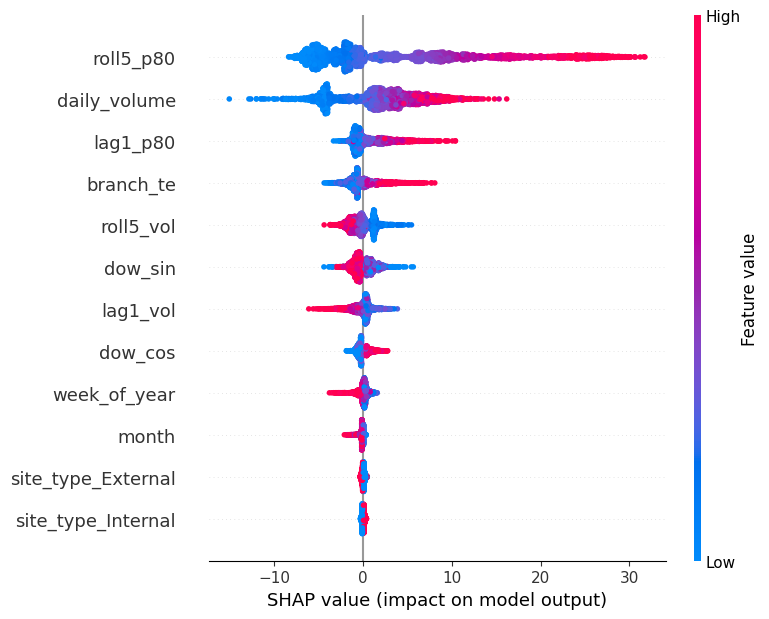

In [13]:
import shap

gbm_pipe = results["Gradient Boosting"]["pipeline"]

# Transform features through the preprocessor
X_test_transformed = gbm_pipe.named_steps["preprocessor"].transform(X_test)

ohe_names = list(
    gbm_pipe.named_steps["preprocessor"]
    .named_transformers_["cat"]
    .get_feature_names_out(CAT_FEATURES)
)
transformed_feature_names = NUM_FEATURES + ohe_names

explainer   = shap.TreeExplainer(gbm_pipe.named_steps["model"])
shap_values = explainer.shap_values(X_test_transformed)

# Beeswarm summary
fig, ax = plt.subplots(figsize=(9, 6))
shap.summary_plot(
    shap_values, X_test_transformed,
    feature_names=transformed_feature_names,
    plot_type="dot", show=False, max_display=12,
)
plt.tight_layout()
plt.savefig(OUTF + "03_shap_summary.png", dpi=150, bbox_inches="tight")
print("Saved -> outputs/figures/03_shap_summary.png")

Highest-error test observation:
  Branch: #076  Date: 2025-08-04
  Observed p80: 0.3 min  |  Predicted: 53.8 min  |  Error: 53.5 min
Saved -> outputs/figures/03_shap_waterfall.png


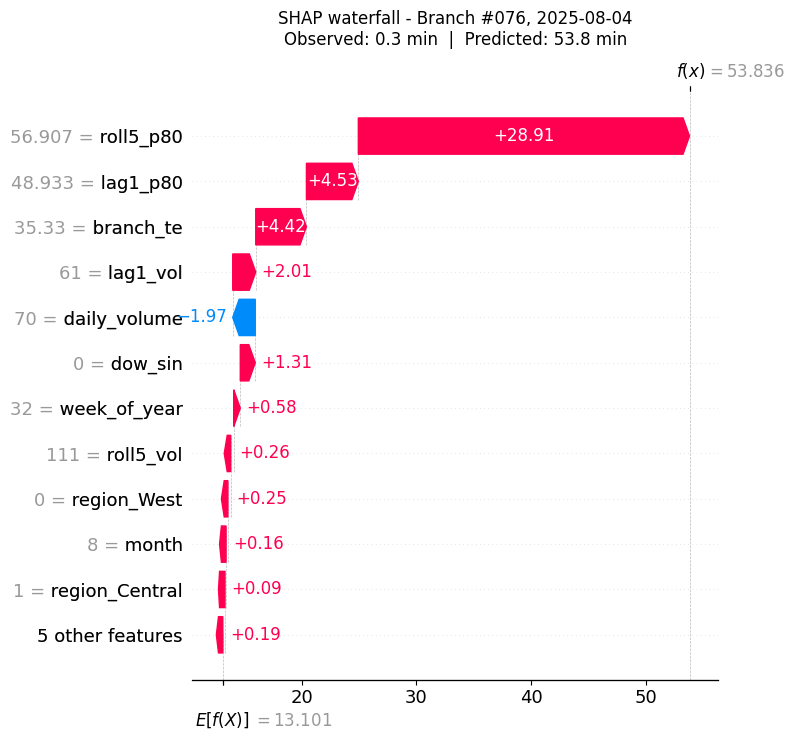

In [15]:
# Waterfall plot for the single highest-error test observation
abs_errors = np.abs(
    results["Gradient Boosting"]["y_pred"] - y_test.values
)
worst_idx = abs_errors.argmax()

obs_val   = y_test.values[worst_idx]
pred_val  = results["Gradient Boosting"]["y_pred"][worst_idx]
branch_id = test.iloc[worst_idx]["Branch ID"]
date_val  = test.iloc[worst_idx]["Visit Date"].date()

print(f"Highest-error test observation:")
print(f"  Branch: {branch_id}  Date: {date_val}")
print(f"  Observed p80: {obs_val:.1f} min  |  Predicted: {pred_val:.1f} min  |  Error: {abs_errors[worst_idx]:.1f} min")

shap_exp = shap.Explanation(
    values         = shap_values[worst_idx],
    base_values    = explainer.expected_value,
    data           = X_test_transformed[worst_idx],
    feature_names  = transformed_feature_names,
)

fig, ax = plt.subplots(figsize=(9, 6))
shap.waterfall_plot(shap_exp, max_display=12, show=False)
plt.title(
    f"SHAP waterfall - Branch {branch_id}, {date_val}\n"
    f"Observed: {obs_val:.1f} min  |  Predicted: {pred_val:.1f} min",
    pad=12,
)
plt.tight_layout()
plt.savefig(OUTF + "03_shap_waterfall.png", dpi=150, bbox_inches="tight")
print("Saved -> outputs/figures/03_shap_waterfall.png")

## 8. Save gradient boosting pipeline

The gradient boosting pipeline is serialized for use in Notebook 04, which builds a 30-day branch-level forecast and evaluates threshold-based alerting logic.

In [ ]:
gbm_pipeline.fit(X_train, y_train)
joblib.dump(gbm_pipeline, OUTM + "gbm_wait_time_pipeline.joblib")
print("Saved -> models/gbm_wait_time_pipeline.joblib")

Saved -> models/gbm_wait_time_pipeline.joblib


: 

## Summary

| Item | Detail |
|---|---|
| CV method | TimeSeriesSplit, 5 folds, training data only (2024-01-04 to 2025-07-15) |
| Test R² (Ridge) | 0.72, MAE = 6.12 min, RMSE = 8.860 min |
| Test R² (Random Forest) | 0.73, MAE = 5.99 min, RMSE = 8.76 min |
| Test R² (Gradient Boosting) | 0.71, MAE = 6.13 min, RMSE = 9.06 min |
| Error pattern | MAE rises sharply with volume: ~0.5 min at very low volume, ~7.2 min at the highest volume band |
| GBM top features (permutation) | `roll5_p80` (0.55), `daily_volume` (0.31), `lag1_p80` (0.05) |
| Key takeaway | All three models are competitive; RF showing a consistent ~0.01 R² edge over Ridge across CV folds. The dominant error source is high-volume branch-days where wait-time variance is structurally higher |

Next: **Notebook 04** uses the gradient boosting pipeline to produce 30-day branch-level forecasts and implements a threshold-based alerting system for branches predicted to exceed service targets.